In [1]:
# ============================================================
# CELL 1 - Install dependencies
# ============================================================
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 59.9 MB/s eta 0:00:00


In [2]:
# ============================================================
# CELL 2 - Imports
# ============================================================
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from google.colab import files
from ultralytics import YOLO
from PIL import Image
import io

print("All imports successful!")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
All imports successful!


In [3]:
# ============================================================
# CELL 2 - Set your paths here
# ============================================================
MODEL_PATH = "/content/drive/MyDrive/minor project/best.pt"        # path to your model
IMAGE_PATH = "/content/drive/MyDrive/minor project/test_77.jpg" # path to your test image

# If you have multiple test images in a folder:
# IMAGE_FOLDER = "/content/drive/MyDrive/test_images/"

In [4]:
# ============================================================
# CELL 3 - Load model and image
# ============================================================
import cv2
import numpy as np
from ultralytics import YOLO

model   = YOLO(MODEL_PATH)
img_bgr = cv2.imread(IMAGE_PATH)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

print(f"Model loaded: {MODEL_PATH}")
print(f"Image loaded: {img_rgb.shape}")

Model loaded: /content/drive/MyDrive/minor project/best.pt
Image loaded: (4208, 3120, 3)


Detected 236 objects


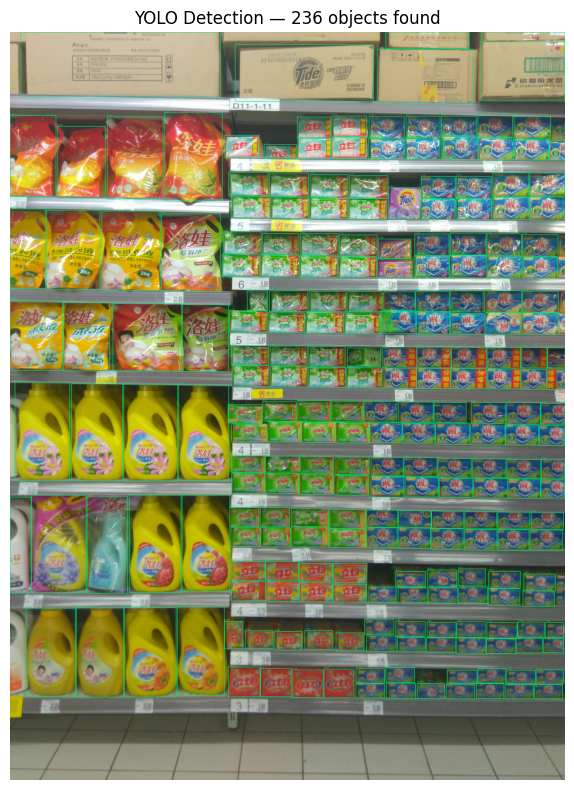

In [6]:
# ============================================================
# CELL 4 - Load image from Drive path
# ============================================================
img_bgr = cv2.imread(IMAGE_PATH)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Run YOLO detection
results = model(img_rgb, conf=0.25, iou=0.45, verbose=False)[0]
boxes   = results.boxes.xyxy.cpu().numpy().astype(int)
confs   = results.boxes.conf.cpu().numpy()

print(f"Detected {len(boxes)} objects")

# Draw boxes on image
vis = img_rgb.copy()
for box, conf in zip(boxes, confs):
    x1, y1, x2, y2 = box
    cv2.rectangle(vis, (x1,y1), (x2,y2), (0,230,120), 2)
    cv2.putText(vis, f"{conf:.2f}", (x1, y1-4),
                cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0,230,120), 1)

plt.figure(figsize=(16, 8))
plt.imshow(vis)
plt.title(f"YOLO Detection — {len(boxes)} objects found")
plt.axis("off")
plt.tight_layout()
plt.show()

236 valid crops extracted


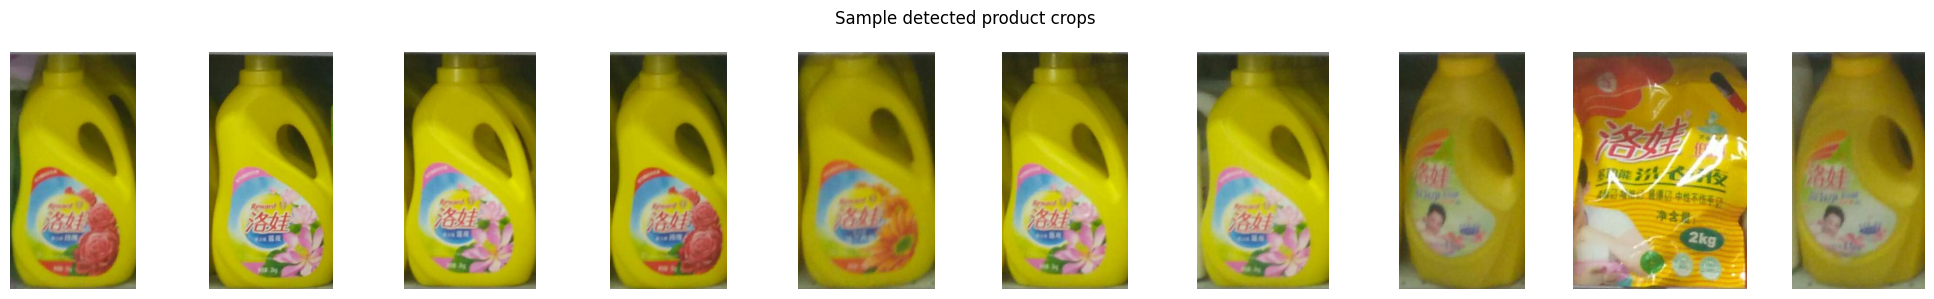

In [7]:
# ============================================================
# CELL 5 - Crop all detected objects
# ============================================================
MIN_SIZE = 20  # ignore tiny boxes

crops = []
valid_boxes = []

for box in boxes:
    x1, y1, x2, y2 = box
    w, h = x2-x1, y2-y1
    if w < MIN_SIZE or h < MIN_SIZE:
        continue
    crop = img_rgb[y1:y2, x1:x2]
    crops.append(crop)
    valid_boxes.append(box)

print(f"{len(crops)} valid crops extracted")

# Preview first 10 crops
n_preview = min(10, len(crops))
fig, axes = plt.subplots(1, n_preview, figsize=(20, 3))
if n_preview == 1:
    axes = [axes]
for ax, crop in zip(axes, crops[:n_preview]):
    ax.imshow(crop)
    ax.axis("off")
plt.suptitle("Sample detected product crops")
plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# CELL 6 - SIFT feature extraction on all crops
# ============================================================
sift = cv2.SIFT_create(nfeatures=500)

def extract_sift(crop_rgb):
    """Extract SIFT keypoints and descriptors from a crop."""
    gray = cv2.cvtColor(crop_rgb, cv2.COLOR_RGB2GRAY)
    # Resize small crops so SIFT has enough pixels to work with
    h, w = gray.shape
    if h < 64 or w < 64:
        scale = max(64/h, 64/w)
        gray  = cv2.resize(gray, (int(w*scale), int(h*scale)))
    kp, des = sift.detectAndCompute(gray, None)
    return kp, des

all_kp  = []
all_des = []

for i, crop in enumerate(crops):
    kp, des = extract_sift(crop)
    all_kp.append(kp)
    all_des.append(des)

valid_count = sum(1 for d in all_des if d is not None and len(d) > 0)
print(f"SIFT extracted from {valid_count}/{len(crops)} crops")
print(f"Avg keypoints per crop: {np.mean([len(k) for k in all_kp if k]):.0f}")

SIFT extracted from 236/236 crops
Avg keypoints per crop: 190


In [9]:
# ============================================================
# CELL 7 - SIFT similarity matching between all crops
# ============================================================
bf      = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)
RATIO   = 0.75   # Lowe's ratio test threshold
MIN_MATCH = 8    # minimum good matches to consider similar

def sift_similarity(des1, des2):
    """Return number of good matches between two descriptors."""
    if des1 is None or des2 is None:
        return 0
    if len(des1) < 2 or len(des2) < 2:
        return 0
    try:
        matches = bf.knnMatch(des1, des2, k=2)
        # Lowe's ratio test
        good = [m for m,n in matches if m.distance < RATIO * n.distance]
        return len(good)
    except:
        return 0

# Build similarity matrix
n = len(crops)
sim_matrix = np.zeros((n, n), dtype=int)

for i in range(n):
    for j in range(i+1, n):
        score = sift_similarity(all_des[i], all_des[j])
        sim_matrix[i][j] = score
        sim_matrix[j][i] = score

print(f"Similarity matrix built: {n}x{n}")
print(f"Max matches found: {sim_matrix.max()}")
print(f"Pairs above threshold ({MIN_MATCH}): {(sim_matrix >= MIN_MATCH).sum() // 2}")

Similarity matrix built: 236x236
Max matches found: 110
Pairs above threshold (8): 5368


In [20]:
# ============================================================
# CELL 8 - Group similar products
# ============================================================
MIN_MATCH = 8

def group_products(sim_matrix, threshold):
    n      = len(sim_matrix)
    labels = [-1] * n
    group  = 0
    for i in range(n):
        if labels[i] == -1:
            labels[i] = group
            for j in range(i+1, n):
                if labels[j] == -1 and sim_matrix[i][j] >= threshold:
                    labels[j] = group
            group += 1
    return labels

labels      = group_products(sim_matrix, MIN_MATCH)
group_sizes = {}
for l in labels:
    group_sizes[l] = group_sizes.get(l, 0) + 1

n_groups    = len(set(labels))
n_singleton = sum(1 for s in group_sizes.values() if s == 1)
n_matched   = sum(1 for s in group_sizes.values() if s > 1)

print(f"\nTotal groups:          {n_groups}")
print(f"Matched groups (>1):   {n_matched}")
print(f"Unmatched singletons:  {n_singleton}")
print(f"\nGroup sizes:")
for gid, size in sorted(group_sizes.items(), key=lambda x: -x[1])[:10]:
    print(f"  Group {gid}: {size} items")


Total groups:          30
Matched groups (>1):   13
Unmatched singletons:  17

Group sizes:
  Group 2: 47 items
  Group 4: 40 items
  Group 5: 30 items
  Group 3: 24 items
  Group 8: 19 items
  Group 0: 17 items
  Group 6: 12 items
  Group 11: 12 items
  Group 7: 8 items
  Group 9: 3 items


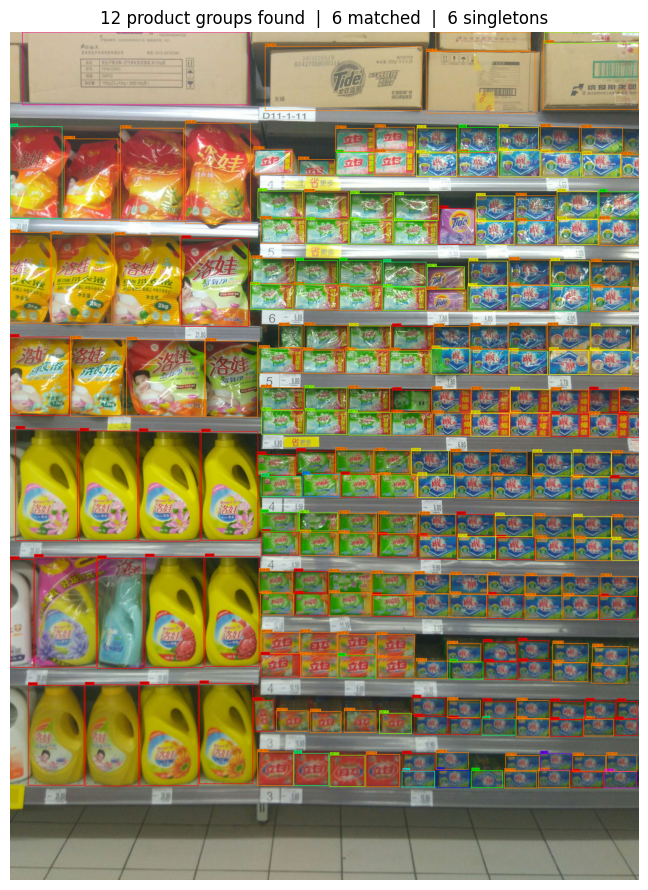

In [16]:
# ============================================================
# CELL 9 - Visualize groups on image
#           Each group gets a unique color
# ============================================================
import random
random.seed(42)

# Generate a distinct color per group
def gen_colors(n):
    colors = []
    for i in range(n):
        hue    = int(360 * i / n)
        color  = plt.cm.hsv(i / n)
        colors.append(tuple(int(c * 255) for c in color[:3]))
    return colors

n_groups    = len(set(labels))
color_list  = gen_colors(n_groups)
group_color = {gid: color_list[gid % len(color_list)] for gid in set(labels)}

output = img_rgb.copy()
for i, (box, label) in enumerate(zip(valid_boxes, labels)):
    x1, y1, x2, y2 = box
    color = group_color[label]
    count = group_sizes[label]

    cv2.rectangle(output, (x1,y1), (x2,y2), color, 2)

    tag = f"G{label}({count})"
    (tw, th), _ = cv2.getTextSize(tag, cv2.FONT_HERSHEY_SIMPLEX, 0.38, 1)
    cv2.rectangle(output, (x1, y1-th-5), (x1+tw+4, y1), color, -1)
    cv2.putText(output, tag, (x1+2, y1-3),
                cv2.FONT_HERSHEY_SIMPLEX, 0.38, (10,10,10), 1)

plt.figure(figsize=(18, 9))
plt.imshow(output)
plt.title(f"{n_groups} product groups found  |  {n_matched} matched  |  {n_singleton} singletons")
plt.axis("off")
plt.tight_layout()
plt.show()

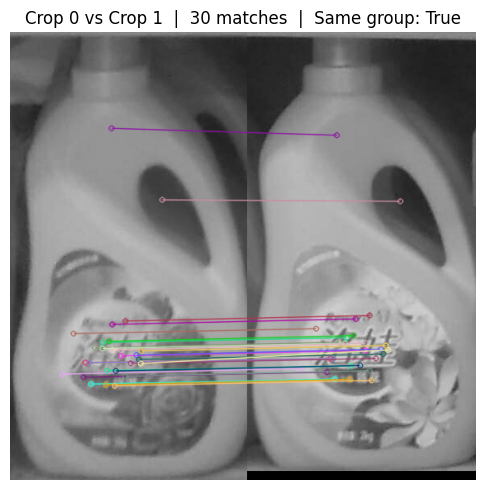

In [17]:
# ============================================================
# CELL 10 - Debug: visualize SIFT matches between two crops
# ============================================================
CROP_A = 0  # change to any crop index
CROP_B = 1  # change to any crop index

def show_matches(idx_a, idx_b):
    gray_a = cv2.cvtColor(crops[idx_a], cv2.COLOR_RGB2GRAY)
    gray_b = cv2.cvtColor(crops[idx_b], cv2.COLOR_RGB2GRAY)

    kp_a, des_a = sift.detectAndCompute(gray_a, None)
    kp_b, des_b = sift.detectAndCompute(gray_b, None)

    if des_a is None or des_b is None:
        print("Not enough keypoints")
        return

    matches  = bf.knnMatch(des_a, des_b, k=2)
    good     = [m for m,n in matches if m.distance < RATIO * n.distance]
    same_grp = labels[idx_a] == labels[idx_b]

    match_img = cv2.drawMatches(
        gray_a, kp_a, gray_b, kp_b, good[:30], None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )

    plt.figure(figsize=(16, 5))
    plt.imshow(match_img, cmap="gray")
    plt.title(f"Crop {idx_a} vs Crop {idx_b}  |  {len(good)} matches  |  Same group: {same_grp}")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

show_matches(CROP_A, CROP_B)

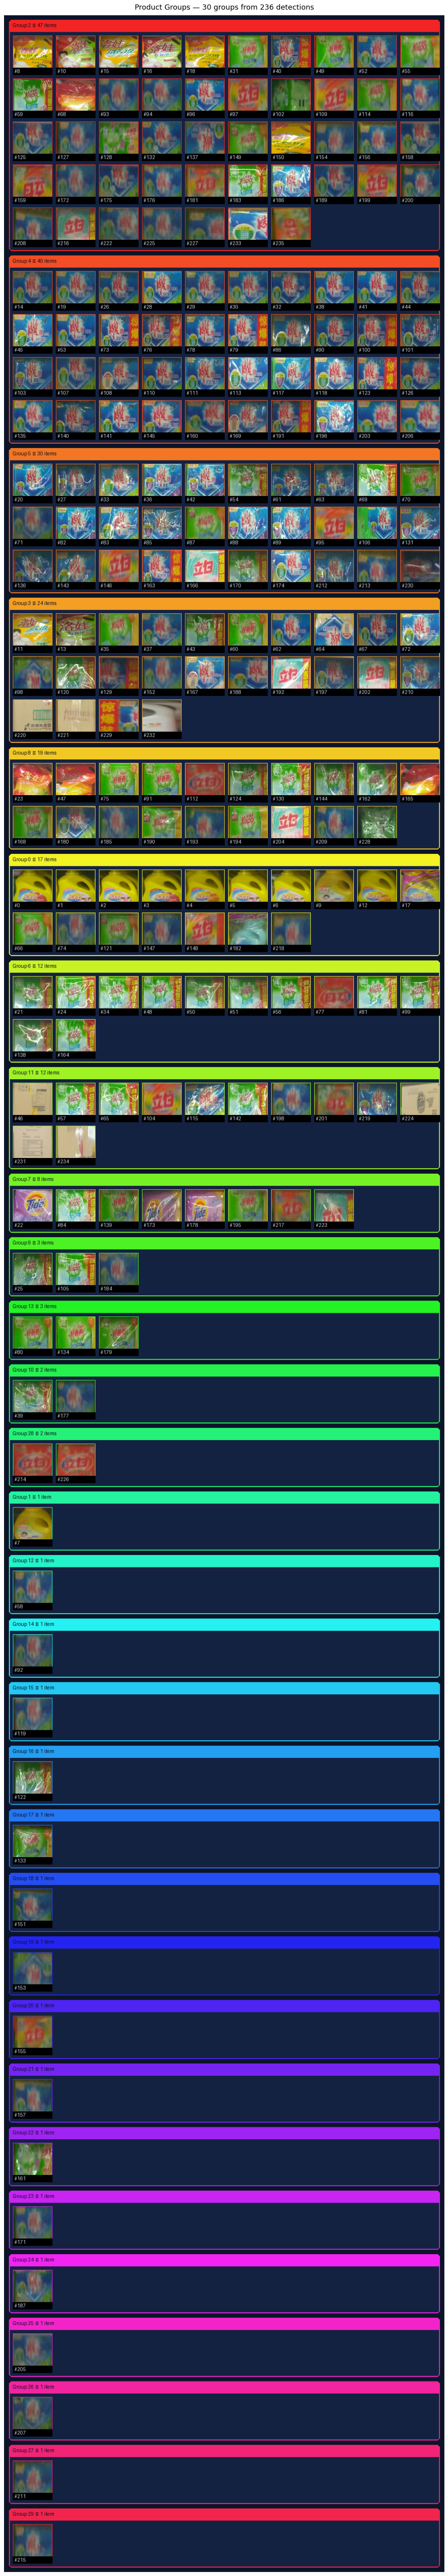

In [21]:
# ============================================================
# CELL - Visualize groups with cropped images
# ============================================================
from PIL import Image as PILImage, ImageDraw, ImageFont
import math

# Group crops by label
groups = {}
for i, (crop, label) in enumerate(zip(crops, labels)):
    if label not in groups:
        groups[label] = []
    groups[label].append((i, crop))

# Sort groups by size (largest first)
sorted_groups = sorted(groups.items(), key=lambda x: -len(x[1]))

# ── layout config ──────────────────────────────────────────
THUMB_W     = 80    # width of each crop thumbnail
THUMB_H     = 80    # height of each crop thumbnail
PADDING     = 8     # space between thumbnails
HEADER_H    = 24    # group header bar height
MARGIN      = 10    # outer margin
MAX_PER_ROW = 10    # max thumbnails per row before wrapping

# Generate distinct colors for groups
def hsv_to_rgb(h, s, v):
    import colorsys
    r, g, b = colorsys.hsv_to_rgb(h, s, v)
    return (int(r*255), int(g*255), int(b*255))

group_colors = {}
for i, (gid, _) in enumerate(sorted_groups):
    group_colors[gid] = hsv_to_rgb(i / max(len(sorted_groups), 1), 0.85, 0.95)

# ── calculate canvas size ───────────────────────────────────
def calc_group_height(n_items):
    rows = math.ceil(n_items / MAX_PER_ROW)
    return HEADER_H + rows * (THUMB_H + PADDING) + PADDING

total_height = MARGIN
for gid, items in sorted_groups:
    total_height += calc_group_height(len(items)) + MARGIN

canvas_w = MARGIN + MAX_PER_ROW * (THUMB_W + PADDING) + MARGIN
canvas   = PILImage.new("RGB", (canvas_w, total_height), (12, 20, 40))
draw_pil = ImageDraw.Draw(canvas)

try:
    fnt_header = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 12)
    fnt_idx    = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 9)
except:
    fnt_header = ImageFont.load_default()
    fnt_idx    = fnt_header

# ── draw each group ─────────────────────────────────────────
cursor_y = MARGIN

for gid, items in sorted_groups:
    color   = group_colors[gid]
    n_items = len(items)
    n_rows  = math.ceil(n_items / MAX_PER_ROW)
    gh      = calc_group_height(n_items)

    # group background
    draw_pil.rounded_rectangle(
        [MARGIN, cursor_y, canvas_w - MARGIN, cursor_y + gh],
        radius=6, fill=(20, 34, 65), outline=color, width=2
    )

    # header bar
    draw_pil.rounded_rectangle(
        [MARGIN, cursor_y, canvas_w - MARGIN, cursor_y + HEADER_H],
        radius=6, fill=color
    )
    draw_pil.rectangle(
        [MARGIN, cursor_y + HEADER_H//2,
         canvas_w - MARGIN, cursor_y + HEADER_H],
        fill=color
    )
    draw_pil.text(
        (MARGIN + 8, cursor_y + 5),
        f"Group {gid}  —  {n_items} item{'s' if n_items > 1 else ''}",
        font=fnt_header, fill=(10, 18, 35)
    )

    # thumbnails
    for idx, (orig_idx, crop) in enumerate(items):
        row = idx // MAX_PER_ROW
        col = idx  % MAX_PER_ROW

        tx = MARGIN + PADDING + col * (THUMB_W + PADDING)
        ty = cursor_y + HEADER_H + PADDING + row * (THUMB_H + PADDING)

        # resize crop to thumbnail
        pil_crop = PILImage.fromarray(crop)
        pil_crop = pil_crop.resize((THUMB_W, THUMB_H), PILImage.LANCZOS)

        canvas.paste(pil_crop, (tx, ty))

        # border around thumbnail
        draw_pil.rectangle(
            [tx, ty, tx + THUMB_W, ty + THUMB_H],
            outline=color, width=1
        )

        # crop index label
        draw_pil.rectangle(
            [tx, ty + THUMB_H - 14, tx + THUMB_W, ty + THUMB_H],
            fill=(0, 0, 0)
        )
        draw_pil.text(
            (tx + 3, ty + THUMB_H - 13),
            f"#{orig_idx}", font=fnt_idx, fill=(200, 210, 230)
        )

    cursor_y += gh + MARGIN

# ── display ─────────────────────────────────────────────────
plt.figure(figsize=(canvas_w / 80, total_height / 80))
plt.imshow(np.array(canvas))
plt.title(f"Product Groups — {len(sorted_groups)} groups from {len(crops)} detections",
          fontsize=13, pad=10)
plt.axis("off")
plt.tight_layout()
plt.show()